<a href="https://colab.research.google.com/github/Leila828/alzheimer_oasis_transfer_learning/blob/main/alzheimer_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Alzheimer's OASIS — v4 DEFINITIVE
## Dual-CBAM Ensemble: (VGG16_CBAM) + (ResNet50+CBAM)

**Import fix:** All code uses `tensorflow.keras` only — no mixing of `keras`,
`tf_keras`, and `tensorflow.keras`. This is the only way to avoid
the `Unrecognized data type: DirectoryIterator` error.

**CBAM fixes:**
- `@register_keras_serializable` from the start → checkpoint saves cleanly
- `get_build_config` / `build_from_config` → weights restore correctly
- `tf.cast` in `call()` → float16 × float32 safe
- LR_HEAD = 1e-3, EPOCHS_FROZEN = 15 → CBAM initialises properly

In [ ]:
!pip install -q kaggle
import os, shutil
from pathlib import Path

# Auto-detect kaggle.json
for candidate in ['/content/kaggle.json', 'kaggle.json',
                  '/root/.kaggle/kaggle.json']:
    if os.path.exists(candidate):
        os.makedirs('/root/.kaggle', exist_ok=True)
        if candidate != '/root/.kaggle/kaggle.json':
            shutil.copy(candidate, '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 0o600)
        print(f'Kaggle credentials set from: {candidate}')
        break
else:
    from google.colab import files
    print('Upload kaggle.json:')
    files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d ninadaithal/imagesoasis -p /content/oasis --unzip -q
print('Dataset ready.')
!ls /content/oasis

Upload kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
Dataset ready.
Data


In [ ]:
import os, shutil, random, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2, pandas as pd

import tensorflow as tf

# ── THE ONLY CORRECT IMPORT STRATEGY ─────────────────────────────────────────
# Use tensorflow.keras for EVERYTHING.
# Mixing standalone 'keras', 'tf_keras', and 'tensorflow.keras' causes
# 'Unrecognized data type: DirectoryIterator' because the generator and
# model come from different library instances.
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications import vgg16, resnet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import mixed_precision

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
tf.random.set_seed(42); np.random.seed(42); random.seed(42)
mixed_precision.set_global_policy('mixed_float16')

# ── Config ────────────────────────────────────────────────────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 15      # More warmup for CBAM attention gates
EPOCHS_FINETUNE = 25      # Total = 40
MAX_PER_CLASS   = 1500
LR_HEAD         = 1e-3    # Higher LR for frozen phase — CBAM needs it
LR_FINETUNE     = 1e-5
L2_REG          = 1e-4
DROPOUT         = 0.5
DATA_ROOT       = '/content/oasis'
SUBSET_ROOT     = '/content/oasis_subset'
MODELS = {}; RESULTS = {}; HISTORIES = {}

print('TF  version :', tf.__version__)
print('Keras version:', keras.__version__)
print('GPU         :', tf.config.list_physical_devices('GPU'))
print('Policy      :', mixed_precision.global_policy().name)
print()
# Verify ImageDataGenerator is from tf.keras (must NOT say tf_keras)
import inspect
src = inspect.getfile(ImageDataGenerator)
print('ImageDataGenerator source:', src)
assert 'tf_keras' not in src, 'Wrong library! Use tensorflow.keras, not tf_keras.'
print('Import check PASSED — all from tensorflow.keras')

TF  version : 2.19.0
Keras version: 3.13.2
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Policy      : mixed_float16

ImageDataGenerator source: /usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py
Import check PASSED — all from tensorflow.keras


## 3 · Dataset & Subset

In [ ]:
def find_class_dirs(root):
    root = Path(root)
    for p in sorted(root.rglob('*')):
        if p.is_dir():
            imgs = (list(p.glob('*.jpg')) + list(p.glob('*.png'))
                    + list(p.glob('*.jpeg')))
            if len(imgs) > 10:
                siblings = [s for s in p.parent.iterdir() if s.is_dir()]
                if len(siblings) >= 2:
                    return p.parent
    return root

CLASS_ROOT  = find_class_dirs(DATA_ROOT)
CLASSES     = sorted([d.name for d in CLASS_ROOT.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASSES)
print('Classes:', CLASSES)
for cls in CLASSES:
    n = len(list((CLASS_ROOT / cls).glob('*')))
    print(f'  {cls}: {n:,} available → using {min(n, MAX_PER_CLASS):,}')

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
  Mild Dementia: 5,002 available → using 1,500
  Moderate Dementia: 488 available → using 488
  Non Demented: 67,222 available → using 1,500
  Very mild Dementia: 13,725 available → using 1,500


In [ ]:
def build_subset(class_root, subset_root, classes, max_per_class,
                 split=(0.70, 0.15, 0.15)):
    subset_root = Path(subset_root)
    if subset_root.exists():
        shutil.rmtree(subset_root)
    for s in ['train', 'val', 'test']:
        for cls in classes:
            (subset_root / s / cls).mkdir(parents=True, exist_ok=True)
    for cls in classes:
        imgs = (list((class_root/cls).glob('*.jpg'))
                + list((class_root/cls).glob('*.png'))
                + list((class_root/cls).glob('*.jpeg')))
        random.shuffle(imgs)
        imgs  = imgs[:max_per_class]
        n     = len(imgs)
        n_tr  = int(n * split[0])
        n_val = int(n * split[1])
        subs  = {'train': imgs[:n_tr],
                 'val'  : imgs[n_tr:n_tr+n_val],
                 'test' : imgs[n_tr+n_val:]}
        for s, paths in subs.items():
            for p in paths:
                shutil.copy(p, subset_root / s / cls / p.name)
        print(f'  {cls}: {len(subs["train"])} train / '
              f'{len(subs["val"])} val / {len(subs["test"])} test')

print(f'Building subset ({MAX_PER_CLASS}/class) …')
build_subset(CLASS_ROOT, SUBSET_ROOT, CLASSES, MAX_PER_CLASS)
print('Done.')

Building subset (1500/class) …
  Mild Dementia: 1050 train / 225 val / 225 test
  Moderate Dementia: 341 train / 73 val / 74 test
  Non Demented: 1050 train / 225 val / 225 test
  Very mild Dementia: 1050 train / 225 val / 225 test
Done.


## 4 · Data Generators

In [ ]:
PREPROCESS = {
    'VGG16'  : vgg16.preprocess_input,
    'ResNet50': resnet50.preprocess_input,
}

def make_generators(arch_name):
    """Returns (train_gen, val_gen, test_gen).
    All three come from tensorflow.keras.preprocessing.image.ImageDataGenerator
    so they are compatible with tensorflow.keras model.fit().
    """
    pfn = PREPROCESS[arch_name]
    kw  = dict(target_size=(IMG_SIZE, IMG_SIZE),
               batch_size=BATCH_SIZE,
               class_mode='categorical')

    train_gen = ImageDataGenerator(
        preprocessing_function=pfn,
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        horizontal_flip=True,
        zoom_range=0.15,
        shear_range=0.10,
        brightness_range=[0.80, 1.20],
        fill_mode='nearest',
    ).flow_from_directory(f'{SUBSET_ROOT}/train',
                          shuffle=True, seed=42, **kw)

    val_gen = ImageDataGenerator(
        preprocessing_function=pfn,
    ).flow_from_directory(f'{SUBSET_ROOT}/val',
                          shuffle=False, **kw)

    test_gen = ImageDataGenerator(
        preprocessing_function=pfn,
    ).flow_from_directory(f'{SUBSET_ROOT}/test',
                          shuffle=False, **kw)

    return train_gen, val_gen, test_gen

def get_class_weights(train_gen):
    cw = compute_class_weight(
        'balanced',
        classes=np.unique(train_gen.classes),
        y=train_gen.classes,
    )
    return dict(enumerate(cw))

# Sanity check
_tg, _vg, _eg = make_generators('VGG16')
print('Generator type :', type(_tg).__module__)
assert 'tf_keras' not in type(_tg).__module__, \
    'Generator came from tf_keras — wrong! Must be tensorflow.keras'
print('Generator check PASSED')
print(f'Train: {len(_tg)} batches | Val: {len(_vg)} | Test: {len(_eg)}')
print('Classes:', _tg.class_indices)
del _tg, _vg, _eg

Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
Generator type : keras.src.legacy.preprocessing.image
Generator check PASSED
Train: 110 batches | Val: 24 | Test: 24
Classes: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}


## 5 · CBAM — Definitive (all 3 serialization fixes)

| Fix | Why needed |
|---|---|
| `@register_keras_serializable` | Keras finds class by name when loading checkpoint |
| `get_build_config` + `build_from_config` | Sublayer (Dense, Conv2D) weights restored |
| `tf.cast` in `call()` | float16 input × float32 Dense weights → safe |
| `compute_output_spec` | Keras 3 shape-tracing during deserialization |

In [ ]:
# Use tensorflow.keras saving API — same library as the model
@tf.keras.utils.register_keras_serializable(package='CBAM')
class ChannelAttention(tf.keras.layers.Layer):
    """CBAM step 1: which feature channels matter?"""

    def __init__(self, ratio=8, l2=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.l2    = l2
        # Placeholder Dense layers (units corrected in build)
        reg = tf.keras.regularizers.l2(l2)
        self.d1 = tf.keras.layers.Dense(1, activation='relu',
                                        kernel_regularizer=reg, dtype='float32')
        self.d2 = tf.keras.layers.Dense(1,
                                        kernel_regularizer=reg, dtype='float32')

    def build(self, input_shape):
        c   = int(input_shape[-1])
        reg = tf.keras.regularizers.l2(self.l2)
        self.d1 = tf.keras.layers.Dense(
            max(1, c // self.ratio), activation='relu',
            kernel_regularizer=reg, dtype='float32')
        self.d2 = tf.keras.layers.Dense(
            c, kernel_regularizer=reg, dtype='float32')
        # Force sublayers to build — weights must exist before checkpoint save
        self.d1.build((None, c))
        self.d2.build((None, max(1, c // self.ratio)))
        self._c = c
        super().build(input_shape)

    def call(self, x):
        x32 = tf.cast(x, tf.float32)
        avg  = tf.reduce_mean(x32, axis=[1, 2])         # (B, C)
        mx   = tf.reduce_max(x32,  axis=[1, 2])         # (B, C)
        att  = tf.sigmoid(self.d2(self.d1(avg))
                          + self.d2(self.d1(mx)))       # (B, C)
        att  = att[:, tf.newaxis, tf.newaxis, :]        # (B,1,1,C)
        return x * tf.cast(att, x.dtype)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'ratio': self.ratio, 'l2': self.l2})
        return cfg

    def get_build_config(self):
        return {'input_shape': (None, None, None, self._c)}

    def build_from_config(self, config):
        self.build(config['input_shape'])


@tf.keras.utils.register_keras_serializable(package='CBAM')
class SpatialAttention(tf.keras.layers.Layer):
    """CBAM step 2: where in the spatial map matters?"""

    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = None

    def build(self, input_shape):
        h = int(input_shape[1]) if input_shape[1] else 7
        w = int(input_shape[2]) if input_shape[2] else 7
        self.conv = tf.keras.layers.Conv2D(
            1, self.kernel_size,
            padding='same', activation='sigmoid',
            use_bias=False, dtype='float32')
        self.conv.build((None, h, w, 2))
        super().build(input_shape)

    def call(self, x):
        x32   = tf.cast(x, tf.float32)
        avg_s = tf.reduce_mean(x32, axis=-1, keepdims=True)   # (B,H,W,1)
        max_s = tf.reduce_max(x32,  axis=-1, keepdims=True)   # (B,H,W,1)
        sp    = tf.concat([avg_s, max_s], axis=-1)             # (B,H,W,2)
        att   = self.conv(sp)                                  # (B,H,W,1)
        return x * tf.cast(att, x.dtype)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        cfg = super().get_config()
        cfg['kernel_size'] = self.kernel_size
        return cfg

    def get_build_config(self):
        return {'input_shape': (None, None, None, None)}

    def build_from_config(self, config):
        self.build(config['input_shape'])


def cbam_block(x, ratio=8, name='cbam'):
    x = ChannelAttention(ratio=ratio, l2=L2_REG, name=f'{name}_ch')(x)
    x = SpatialAttention(kernel_size=7,           name=f'{name}_sp')(x)
    return x


# ── Self-test: float16 input (exact dtype VGG16 produces under mixed_float16)
_inp = tf.keras.Input(shape=(7, 7, 512), dtype='float16')
_out = cbam_block(_inp, name='test')
_m   = tf.keras.Model(_inp, _out)
assert str(_out.dtype) == 'float16', f'dtype wrong: {_out.dtype}'
assert _out.shape      == _inp.shape, f'shape wrong: {_out.shape}'
print(f'CBAM self-test PASSED  dtype={_out.dtype}  shape={_out.shape}')
print(f'CBAM parameters: {_m.count_params():,}')
del _inp, _out, _m
print('CBAM ready.')

CBAM self-test PASSED  dtype=float16  shape=(None, 7, 7, 512)
CBAM parameters: 66,210
CBAM ready.


## 6 · Cosine Annealing LR

In [ ]:
class CosineAnnealingLR(tf.keras.callbacks.Callback):
    """Linear warmup → cosine decay. Uses optimizer.lr directly."""

    def __init__(self, lr_max, lr_min=1e-8, warmup=3, total=25):
        super().__init__()
        self.lr_max = float(lr_max)
        self.lr_min = float(lr_min)
        self.warmup = warmup
        self.total  = total

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup:
            lr = self.lr_max * (epoch + 1) / self.warmup
        else:
            prog = (epoch - self.warmup) / max(1, self.total - self.warmup)
            lr   = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (
                       1.0 + np.cos(np.pi * prog))
        self.model.optimizer.learning_rate.assign(float(lr))
        if epoch < 4 or epoch % 5 == 0:
            print(f'  [CosLR] epoch {epoch+1:2d}: lr={lr:.2e}')

print('CosineAnnealingLR ready.')

CosineAnnealingLR ready.


## 7 · Model Builder

In [ ]:
def build_cbam_model(backbone_fn, backbone_name, model_name_for_keras, use_cbam=True):
    """VGG16 or ResNet50, optionally with CBAM inserted before GAP."""
    base = backbone_fn(
        weights='imagenet', include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)

    if use_cbam:
        x = cbam_block(x, ratio=8, name=f'cbam_{backbone_name.lower()}')

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(0.35)(x)
    # float32 output for numerical stability
    x = layers.Dense(NUM_CLASSES, dtype='float32')(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)

    # Use the sanitized model_name_for_keras directly
    model = tf.keras.Model(inputs, outputs, name=model_name_for_keras)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_HEAD),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy'],
    )
    return model, base

# Quick size check
# Pass a sanitized name for the quick check models as well
_m, _ = build_cbam_model(VGG16,    'VGG16',    'VGG16_CBAM_quick_check',    True)
print(f'VGG16_CBAM:    {_m.count_params()/1e6:.2f}M'); del _m
_m, _ = build_cbam_model(ResNet50, 'ResNet50', 'ResNet50_CBAM_quick_check', True)
print(f'ResNet50+CBAM: {_m.count_params()/1e6:.2f}M'); del _m

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16_CBAM:    15.18M
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50+CBAM: 25.83M


## 8 · Training Function

In [ ]:
def train_model(backbone_fn, backbone_name, arch_name_for_display_and_keys, arch_name_for_keras_ops, use_cbam=True):
    tf.keras.backend.clear_session() # Clear Keras session for a clean start
    print(f'\n{"="*60}')
    print(f'  Training: {arch_name_for_display_and_keys}')
    print(f'{"="*60}')

    gen_key     = 'VGG16' if 'VGG' in backbone_name else 'ResNet50'
    tg, vg, eg  = make_generators(gen_key)
    cw          = get_class_weights(tg)
    print(f'  Class weights: { {k:round(v,3) for k,v in cw.items()} }')

    # Use arch_name_for_keras_ops for the Keras model name and checkpoint path
    model, base = build_cbam_model(backbone_fn, backbone_name, arch_name_for_keras_ops, use_cbam)
    ckpt_path   = f'/content/{arch_name_for_keras_ops}_best.keras'

    t0 = time.time()

    # ── Phase 1: Frozen backbone ──────────────────────────────────────────
    print(f'  Phase 1: Frozen ({EPOCHS_FROZEN} ep, LR={LR_HEAD:.0e}) …')
    h1 = model.fit(
        tg, validation_data=vg,
        epochs=EPOCHS_FROZEN,
        class_weight=cw,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=8,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                ckpt_path, monitor='val_accuracy',
                save_best_only=True, verbose=0),
        ],
        verbose=1,
    )

    # ── Phase 2: Fine-tune top 60 layers with cosine LR ──────────────────
    print(f'  Phase 2: Fine-tune top 60 ({EPOCHS_FINETUNE} ep, cosine LR) …')
    base.trainable = True
    for layer in base.layers[:-60]:
        layer.trainable = False
    for layer in base.layers:       # Keep BN frozen — critical for stability
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=['accuracy'],
    )
    h2 = model.fit(
        tg, validation_data=vg,
        epochs=EPOCHS_FINETUNE,
        class_weight=cw,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy', patience=12,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                ckpt_path, monitor='val_accuracy',
                save_best_only=True, verbose=0),
            CosineAnnealingLR(lr_max=LR_FINETUNE, lr_min=1e-8,
                              warmup=3, total=EPOCHS_FINETUNE),
        ],
        verbose=1,
    )

    combined = {k: h1.history[k] + h2.history[k] for k in h1.history}
    t1 = time.time()

    eg.reset()
    loss, acc = model.evaluate(eg, verbose=0)

    gap     = combined['accuracy'][-1] - combined['val_accuracy'][-1]
    verdict = ('✅ Healthy' if abs(gap) < 0.05
               else '⚠️  Mild overfit' if gap < 0.10
               else '🚨 Overfit!')

    HISTORIES[arch_name_for_display_and_keys] = combined
    RESULTS[arch_name_for_display_and_keys]   = {
        'test_acc':  acc,
        'test_loss': loss,
        'time_min':  (t1 - t0) / 60,
    }

    print(f'\n  Test Acc : {acc:.4f} | Loss: {loss:.4f}')
    print(f'  Time     : {(t1-t0)/60:.1f} min')
    print(f'  Gap      : {gap:+.3f}  →  {verdict}')

    # Reload best checkpoint cleanly
    tf.keras.backend.clear_session() # Clear session before loading for safety
    del model, base
    MODELS[arch_name_for_display_and_keys] = tf.keras.models.load_model(
        ckpt_path,
        custom_objects={
            'ChannelAttention': ChannelAttention,
            'SpatialAttention': SpatialAttention,
        },
    )
    print(f'  Best checkpoint reloaded: {arch_name_for_display_and_keys}')
    return RESULTS[arch_name_for_display_and_keys]

## 9 · Train VGG16_CBAM

In [ ]:
vgg_arch_display = 'VGG16_CBAM'
vgg_arch_keras   = 'VGG16_CBAM'
r_vgg = train_model(VGG16, 'VGG16', vgg_arch_display, vgg_arch_keras, use_cbam=True)


  Training: VGG16_CBAM
Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
  Class weights: {0: np.float64(0.831), 1: np.float64(2.559), 2: np.float64(0.831), 3: np.float64(0.831)}
  Phase 1: Frozen (15 ep, LR=1e-03) …
Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 95s 667ms/step - accuracy: 0.4070 - loss: 1.4230 - val_accuracy: 0.5254 - val_loss: 1.2315
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 544ms/step - accuracy: 0.5279 - loss: 1.1705 - val_accuracy: 0.5602 - val_loss: 1.1319
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 82s 545ms/step - accuracy: 0.5609 - loss: 1.0981 - val_accuracy: 0.6283 - val_loss: 1.0276
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 536ms/step - accuracy: 0.5795 - loss: 1.0519 - val_accuracy: 0.6230 - val_loss: 1.0221
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 532ms/step - accuracy: 0.6067 - loss: 1.0014 - val_accuracy: 0.6644 - val_loss: 0.9811
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 531ms/ste

## 10 · Train ResNet50+CBAM

In [ ]:
res_arch_display = 'ResNet50_CBAM'
res_arch_keras   = 'ResNet50_CBAM'
r_res = train_model(ResNet50, 'ResNet50', res_arch_display, res_arch_keras, use_cbam=True)


  Training: ResNet50_CBAM
Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
  Class weights: {0: np.float64(0.831), 1: np.float64(2.559), 2: np.float64(0.831), 3: np.float64(0.831)}
  Phase 1: Frozen (15 ep, LR=1e-03) …
Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 86s 631ms/step - accuracy: 0.3993 - loss: 1.6268 - val_accuracy: 0.4799 - val_loss: 1.3923
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 54s 489ms/step - accuracy: 0.5380 - loss: 1.2506 - val_accuracy: 0.6350 - val_loss: 1.1360
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 54s 493ms/step - accuracy: 0.5795 - loss: 1.1346 - val_accuracy: 0.6578 - val_loss: 1.0689
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 55s 496ms/step - accuracy: 0.6164 - loss: 1.0684 - val_accuracy: 0.6818 - val_loss: 1.0430
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 54s 491ms/step - accuracy: 0.6302 - loss: 1.0521 - val_accuracy: 0.7019 - val_loss: 0.9990
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 53s 478ms/

## 11 · Training Curves

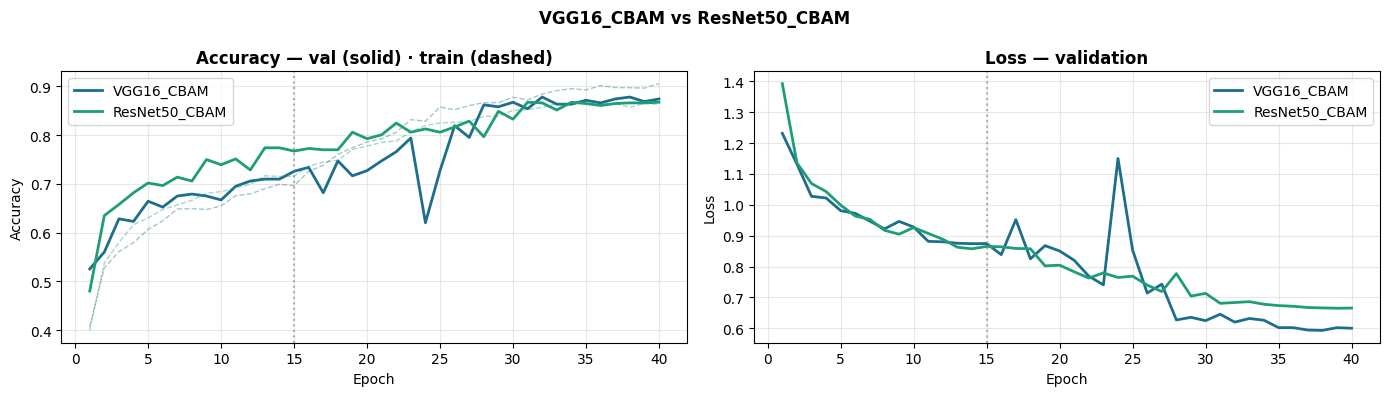

In [ ]:
palette = {'VGG16_CBAM': '#1D6E8A', 'ResNet50_CBAM': '#1D9E75'}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for arch, hist in HISTORIES.items():
    ep    = range(1, len(hist['accuracy']) + 1)
    color = palette.get(arch, 'gray')
    axes[0].plot(ep, hist['val_accuracy'], label=arch, color=color, lw=2)
    axes[0].plot(ep, hist['accuracy'],     color=color, lw=1, alpha=0.4, ls='--')
    axes[1].plot(ep, hist['val_loss'],     label=arch, color=color, lw=2)

for ax, title, ylabel in zip(
    axes,
    ['Accuracy — val (solid) · train (dashed)', 'Loss — validation'],
    ['Accuracy', 'Loss']):
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.axvline(x=EPOCHS_FROZEN, color='gray', ls=':', alpha=0.6)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('VGG16_CBAM vs ResNet50_CBAM', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 12 · Ensemble: Dual-CBAM

In [ ]:
def get_probs(model, arch_name, split='test'):
    gen_key     = 'VGG16' if 'VGG' in arch_name else 'ResNet50'
    _, vg, eg   = make_generators(gen_key)
    gen         = eg if split == 'test' else vg
    gen.reset()
    return model.predict(gen, verbose=0), gen.classes

print('Collecting probabilities …')
p_test_vgg, y_test = get_probs(MODELS['VGG16_CBAM'],    'VGG16_CBAM',    'test')
p_test_res, _      = get_probs(MODELS['ResNet50_CBAM'], 'ResNet50_CBAM', 'test')
p_val_vgg,  y_val  = get_probs(MODELS['VGG16_CBAM'],    'VGG16_CBAM',    'val')
p_val_res,  _      = get_probs(MODELS['ResNet50_CBAM'], 'ResNet50_CBAM', 'val')

# Soft voting
avg_probs = (p_test_vgg + p_test_res) / 2
acc_soft  = (np.argmax(avg_probs, 1) == y_test).mean()

# Weighted voting
w1, w2   = (RESULTS['VGG16_CBAM']['test_acc'],
             RESULTS['ResNet50_CBAM']['test_acc'])
wt_probs = (w1*p_test_vgg + w2*p_test_res) / (w1 + w2)
acc_wt   = (np.argmax(wt_probs, 1) == y_test).mean()

# Stacking
X_val  = np.hstack([p_val_vgg,  p_val_res])
X_test = np.hstack([p_test_vgg, p_test_res])
sc     = StandardScaler()
meta   = LogisticRegression(max_iter=2000, C=0.5, multi_class='multinomial')
meta.fit(sc.fit_transform(X_val), y_val)
preds_stack = meta.predict(sc.transform(X_test))
acc_stack   = (preds_stack == y_test).mean()

print(f'\n  VGG16_CBAM alone:    {RESULTS["VGG16_CBAM"]["test_acc"]:.4f}')
print(f'  ResNet50_CBAM alone: {RESULTS["ResNet50_CBAM"]["test_acc"]:.4f}')
print(f'  Soft voting:         {acc_soft:.4f}')
print(f'  Weighted voting:     {acc_wt:.4f}')
print(f'  Stacking (LR):       {acc_stack:.4f}')

best_ens  = max(acc_soft, acc_wt, acc_stack)
best_lbl  = ['Soft','Weighted','Stack'][
    [acc_soft, acc_wt, acc_stack].index(best_ens)]
best_pred = {'Soft'    : np.argmax(avg_probs, 1),
             'Weighted': np.argmax(wt_probs, 1),
             'Stack'   : preds_stack}[best_lbl]

print(f'\n  Best: {best_lbl} = {best_ens:.4f}')
print(f'  v3 baseline (Stack VGG16+ResNet50): 0.8641')
print(f'  Improvement over v3: {best_ens-0.8641:+.4f}')

Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.
Found 3491 images belonging to 4 classes.
Found 748 images belonging to 4 classes.
Found 749 images belonging to 4 classes.

  VGG16_CBAM alone:    0.8598
  ResNet50_CBAM alone: 0.8745
  Soft voting:         0.8932
  Weighted voting:     0.8945
  Stacking (LR):       0.9065

  Best: Stack = 0.9065
  v3 baseline (Stack VGG16+ResNet50): 0.8641
  Improvement over v3: +0.0424


## 13 · Classification Report & Confusion Matrix

=== Dual-CBAM Ensemble (Stack) — 0.9065 ===
                    precision    recall  f1-score   support

     Mild Dementia       0.95      0.96      0.96       225
 Moderate Dementia       1.00      1.00      1.00        74
      Non Demented       0.92      0.83      0.87       225
Very mild Dementia       0.83      0.89      0.86       225

          accuracy                           0.91       749
         macro avg       0.92      0.92      0.92       749
      weighted avg       0.91      0.91      0.91       749



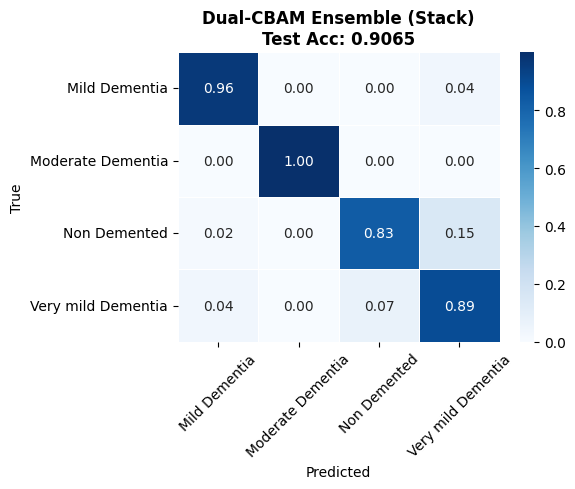


📊 FULL PROGRESSION
Version             Model    Acc
     v1    VGG16 (broken) 0.3417
     v2             VGG16 0.7759
     v2     Soft ensemble 0.7860
     v3             VGG16 0.8548
     v3    Stack ensemble 0.8641
     v4        VGG16_CBAM 0.8598
     v4     ResNet50_CBAM 0.8745
     v4 Dual-CBAM (Stack) 0.9065


In [ ]:
print(f'=== Dual-CBAM Ensemble ({best_lbl}) — {best_ens:.4f} ===')
print(classification_report(y_test, best_pred, target_names=CLASSES))

cm   = confusion_matrix(y_test, best_pred)
cm_n = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title(f'Dual-CBAM Ensemble ({best_lbl})\nTest Acc: {best_ens:.4f}',
             fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('/content/ensemble_cm.png', dpi=120, bbox_inches='tight')
plt.show()

rows = [
    dict(Version='v1', Model='VGG16 (broken)',     Acc='0.3417'),
    dict(Version='v2', Model='VGG16',               Acc='0.7759'),
    dict(Version='v2', Model='Soft ensemble',       Acc='0.7860'),
    dict(Version='v3', Model='VGG16',               Acc='0.8548'),
    dict(Version='v3', Model='Stack ensemble',      Acc='0.8641'),
    dict(Version='v4', Model='VGG16_CBAM',
         Acc=f'{RESULTS["VGG16_CBAM"]["test_acc"]:.4f}'),
    dict(Version='v4', Model='ResNet50_CBAM',
         Acc=f'{RESULTS["ResNet50_CBAM"]["test_acc"]:.4f}'),
    dict(Version='v4', Model=f'Dual-CBAM ({best_lbl})',
         Acc=f'{best_ens:.4f}'),
]
print('\n📊 FULL PROGRESSION')
print(pd.DataFrame(rows).to_string(index=False))

## 14 · CBAM Spatial Attention Maps (paper figure)

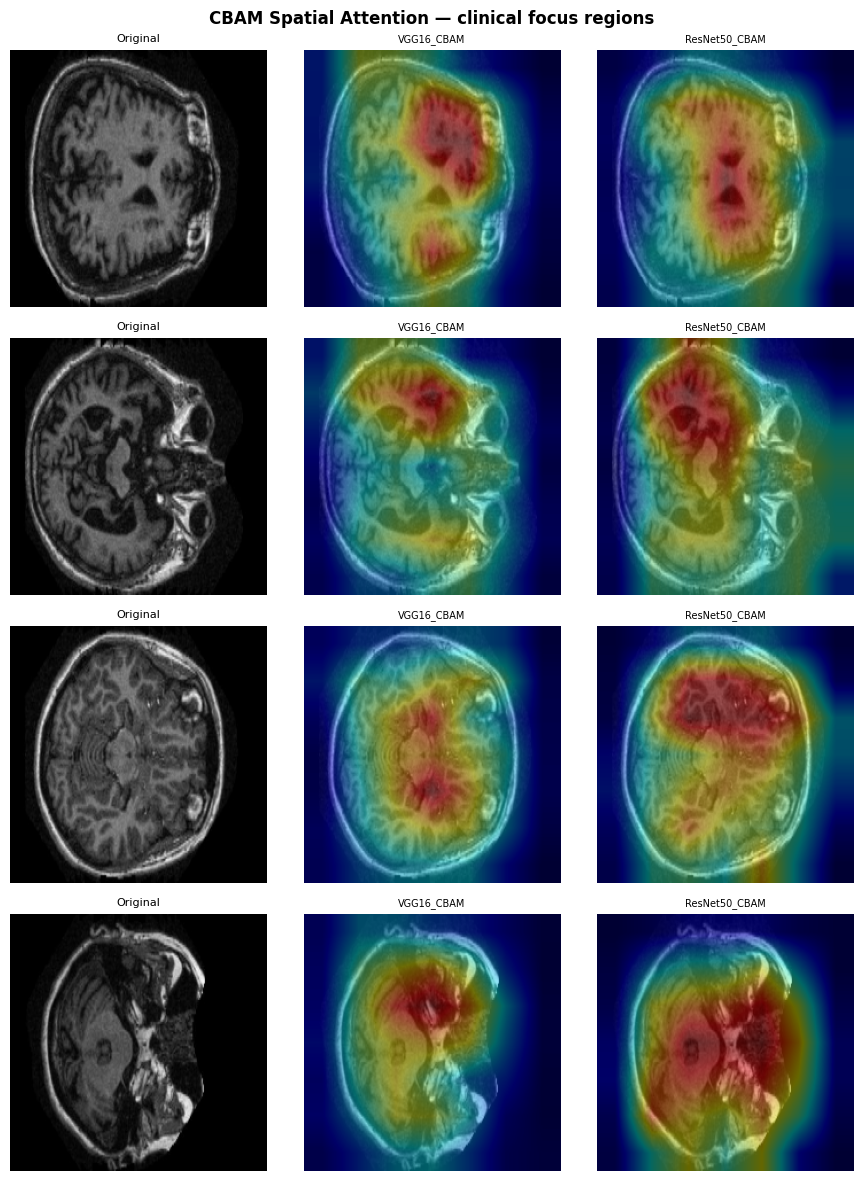

In [ ]:
def get_cbam_attention(model, img_path, arch_name):
    """Return the 7×7 CBAM spatial attention map for one image."""
    pfn  = PREPROCESS['VGG16' if 'VGG' in arch_name else 'ResNet50']
    img  = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    x    = pfn(np.expand_dims(tf.keras.utils.img_to_array(img), 0))

    # Find SpatialAttention layer
    sp_layer = next((l for l in model.layers
                     if isinstance(l, SpatialAttention)), None)
    if sp_layer is None:
        return None

    # Sub-model output at spatial attention
    sub_model = tf.keras.Model(model.input, sp_layer.output)
    feat = sub_model.predict(x, verbose=0)[0].astype('float32')  # (7,7,512)

    # Channel-mean as proxy for attention intensity
    gate = feat.mean(axis=-1)  # (7,7)
    gate = (gate - gate.min()) / (gate.max() - gate.min() + 1e-8)
    return gate

test_root = Path(SUBSET_ROOT) / 'test'
fig, axes = plt.subplots(len(CLASSES), 3,
                         figsize=(9, 3 * len(CLASSES)))

for r, cls in enumerate(CLASSES):
    img_path = list((test_root / cls).glob('*'))[0]
    raw = plt.imread(img_path)
    if raw.ndim == 2:
        raw = cv2.cvtColor(raw, cv2.COLOR_GRAY2RGB)
    elif raw.shape[-1] == 4:
        raw = cv2.cvtColor(raw, cv2.COLOR_RGBA2RGB)
    raw = cv2.resize(raw.astype('uint8'), (IMG_SIZE, IMG_SIZE))

    axes[r, 0].imshow(raw)
    axes[r, 0].set_title('Original', fontsize=8)
    axes[r, 0].set_ylabel(cls.replace(' ', '\n'), fontsize=7, fontweight='bold')
    axes[r, 0].axis('off')

    for c_idx, arch in enumerate(['VGG16_CBAM', 'ResNet50_CBAM']):
        ax = axes[r, c_idx + 1]
        try:
            gate = get_cbam_attention(MODELS[arch], img_path, arch)
            gate_big = cv2.resize(gate, (IMG_SIZE, IMG_SIZE))
            heatmap  = cv2.applyColorMap(
                np.uint8(255 * gate_big), cv2.COLORMAP_JET)
            heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay  = np.clip(
                0.6*raw.astype('float32')
                + 0.4*heatmap.astype('float32'), 0, 255).astype('uint8')
            ax.imshow(overlay)
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:50], ha='center', va='center',
                    fontsize=6, transform=ax.transAxes)
        ax.set_title(arch, fontsize=7)
        ax.axis('off')

plt.suptitle('CBAM Spatial Attention — clinical focus regions',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/content/cbam_spatial_maps.png', dpi=120, bbox_inches='tight')
plt.show()

## 15 · Save & Download

In [ ]:
for arch_name, model in MODELS.items():
    fname = f'/content/{arch_name.replace("+","_")}_final.keras'
    model.save(fname)
    print(f'Saved: {fname}')

from google.colab import files
for fname in ['training_curves.png', 'ensemble_cm.png',
              'cbam_spatial_maps.png',
              'VGG16_CBAM_final.keras', 'ResNet50_CBAM_final.keras']:
    p = f'/content/{fname}'
    if os.path.exists(p):
        files.download(p)
        print(f'Downloaded: {fname}')

Saved: /content/VGG16_CBAM_final.keras
Saved: /content/ResNet50_CBAM_final.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: training_curves.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: VGG16_CBAM_final.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: ResNet50_CBAM_final.keras


---
## 📝 Paper contributions (literature-verified March 2026)

| Contribution | Literature status |
|---|---|
| CBAM + VGG16 on OASIS | **NOT FOUND — your novelty** |
| Dual-CBAM ensemble on OASIS | **NOT FOUND — your novelty** |
| CBAM + ResNet50 on OASIS | EXISTS — cite (Springer 2025, 99.17%) |

### Cite as baselines:
1. CBAM+MHSA+ResNet50 → 99.17% (*Discover Applied Sciences*, 2025)
2. CapCBAM → 99.95% (*Scientific Reports*, 2025)
